In [46]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [47]:
import pandas as pd

In [48]:
ROOT = "./"

training_set = pd.read_csv(ROOT + "Training and Testing Sets/" + "UNSW_NB15_training-set.csv")
testing_set = pd.read_csv(ROOT + "Training and Testing Sets/" + "UNSW_NB15_testing-set.csv")

print(training_set.head())
print(testing_set.head())


   id       dur proto service state  spkts  dpkts  sbytes  dbytes       rate  \
0   1  0.121478   tcp       -   FIN      6      4     258     172  74.087490   
1   2  0.649902   tcp       -   FIN     14     38     734   42014  78.473372   
2   3  1.623129   tcp       -   FIN      8     16     364   13186  14.170161   
3   4  1.681642   tcp     ftp   FIN     12     12     628     770  13.677108   
4   5  0.449454   tcp       -   FIN     10      6     534     268  33.373826   

   ...  ct_dst_sport_ltm  ct_dst_src_ltm  is_ftp_login  ct_ftp_cmd  \
0  ...                 1               1             0           0   
1  ...                 1               2             0           0   
2  ...                 1               3             0           0   
3  ...                 1               3             1           1   
4  ...                 1              40             0           0   

   ct_flw_http_mthd  ct_src_ltm  ct_srv_dst  is_sm_ips_ports  attack_cat  \
0                 0   

In [49]:
# Preprocessing the data

training_set_processed = training_set.copy()
testing_set_processed = testing_set.copy()

training_missing_values = training_set_processed.isnull().sum().sum()
testing_missing_values = testing_set_processed.isnull().sum().sum()
print(f"Number of missing values in training set: {training_missing_values}")
print(f"Number of missing values in testing set: {testing_missing_values}")

training_set_processed = training_set_processed.dropna()
testing_set_processed = testing_set_processed.dropna()
print(f"Number of missing values after dropping: {training_set_processed.isnull().sum().sum()}")
print(f"Number of missing values after dropping: {testing_set_processed.isnull().sum().sum()}")

Number of missing values in training set: 0
Number of missing values in testing set: 0
Number of missing values after dropping: 0
Number of missing values after dropping: 0


# 1. Comparative Security Modeling

## 1.1 Binary Intrusion Detection

In [50]:
X_train_bin = training_set_processed.drop(columns=["attack_cat", "label"])
y_train_bin = training_set_processed["label"]

X_test_bin = testing_set_processed.drop(columns=["attack_cat", "label"])
y_test_bin = testing_set_processed["label"]

In [51]:
# One hot encoding for all categorical features
X_train_bin = pd.get_dummies(X_train_bin)
X_test_bin = pd.get_dummies(X_test_bin)

print(X_train_bin.head())

# Aligner le set de validation sur le train
# On ajoute les colonnes manquantes (remplies de 0) et on supprime les colonnes en trop
X_test_bin = X_test_bin.reindex(columns=X_train_bin.columns, fill_value=False)

print(X_train_bin.head())
print(X_test_bin.head())

   id       dur  spkts  dpkts  sbytes  dbytes       rate  sttl  dttl  \
0   1  0.121478      6      4     258     172  74.087490   252   254   
1   2  0.649902     14     38     734   42014  78.473372    62   252   
2   3  1.623129      8     16     364   13186  14.170161    62   252   
3   4  1.681642     12     12     628     770  13.677108    62   252   
4   5  0.449454     10      6     534     268  33.373826   254   252   

          sload  ...  service_ssl  state_CON  state_ECO  state_FIN  state_INT  \
0  14158.942380  ...        False      False      False       True      False   
1   8395.112305  ...        False      False      False       True      False   
2   1572.271851  ...        False      False      False       True      False   
3   2740.178955  ...        False      False      False       True      False   
4   8561.499023  ...        False      False      False       True      False   

   state_PAR  state_REQ  state_RST  state_URN  state_no  
0      False      Fals

### Tuning XGBClassifier

In [52]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import time

In [54]:
params = {
    'n_estimators': [100, 200, 500, 1000],
    'learning_rate': [0.01,0.05,0.1],
    'max_depth': [3, 5, 7, 9]
}

start_time = time.time()

gs = GridSearchCV(XGBClassifier(n_jobs=-1, objective='binary:logistic'), params, n_jobs=-1, cv=3, scoring='accuracy', verbose=10)
gs.fit(X_train_bin, y_train_bin)

end_time = time.time()

print('Best score:', gs.best_score_)
print('Best params:', gs.best_params_)
print(f"Time taken for grid search: {(end_time - start_time)/60:.1f} minutes")

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best score: 0.7391768040560964
Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Time taken for grid search: 4.5 minutes


### Predictions

In [56]:
### https://xgboost.readthedocs.io/en/release_3.2.0/get_started.html

from xgboost import XGBClassifier
# read data
from sklearn.datasets import load_iris
data = load_iris()

# create model instance
bst = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.01, objective='binary:logistic')
# fit model
bst.fit(X_train_bin, y_train_bin)
# make predictions
preds = bst.predict(X_test_bin)

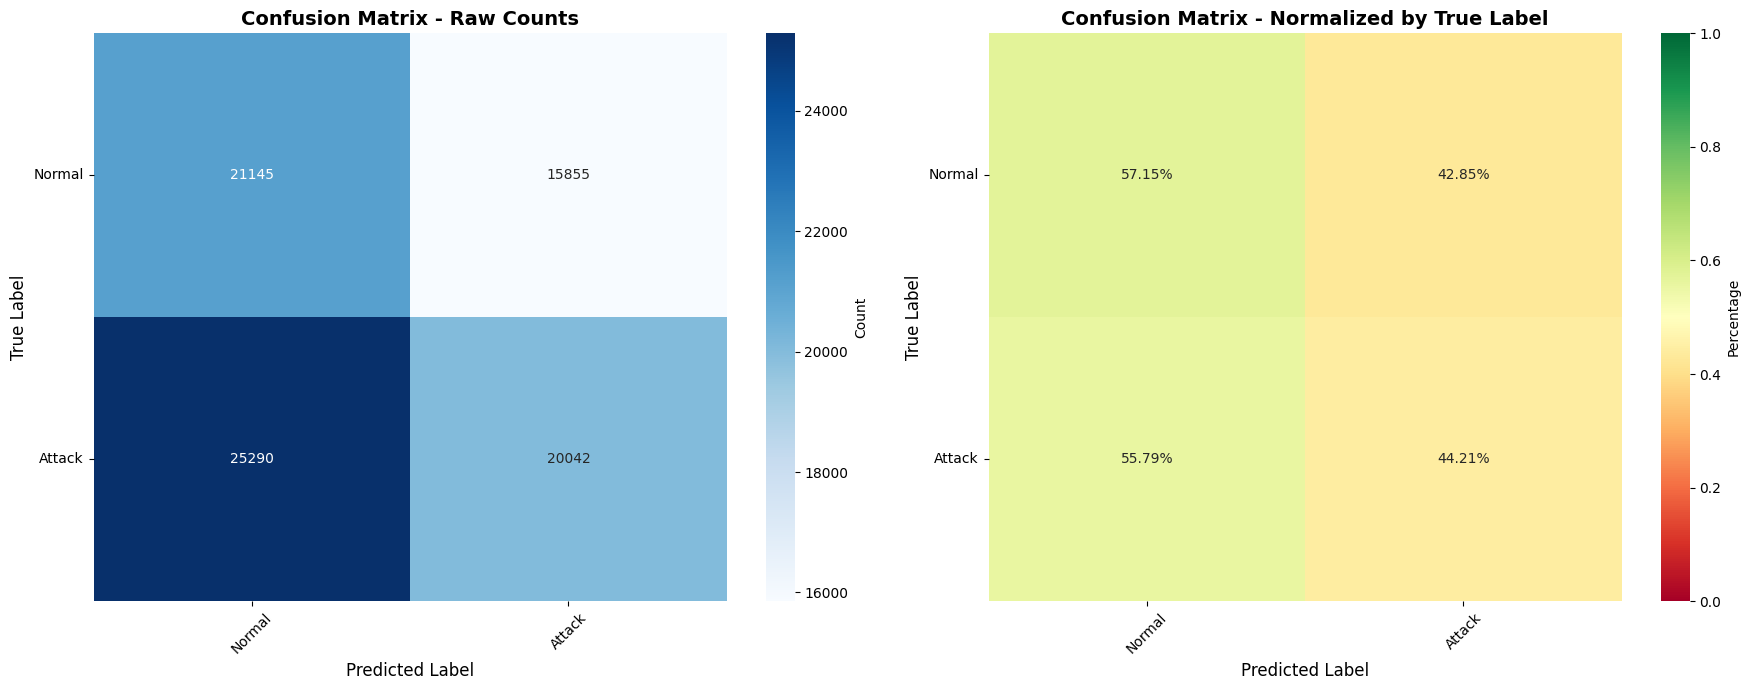

In [57]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
target_names = ['Normal', 'Attack']

cm = confusion_matrix(y_test_bin, preds)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names, yticklabels=target_names,
            cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix - Raw Counts', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Plot 2: Normalized (percentage per true class)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn', ax=axes[1],
            xticklabels=target_names, yticklabels=target_names,
            cbar_kws={'label': 'Percentage'}, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix - Normalized by True Label', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


## 1.2 Class Attack Category Classification

In [58]:
X_train_class = training_set.drop(columns=["attack_cat", "label"])
y_train_class = training_set["attack_cat"]

X_test_class = testing_set.drop(columns=["attack_cat", "label"])
y_test_class = testing_set["attack_cat"]


# 2. Context-Aware Feature Semantics 

## 2.1 Group the dataset features into meaningful cybersecurity categories such as:

## 2.2 Attack Behavior Profiling

# 3. Misclassification and Security Error Analysis

## 3.1 Misclassification and Security Error Analysis

## 3.2 False Positive Security Interpretation

# 4. Trustworthy Security Interpretation (SOC Perspective)

## 4.1 Security-Centric Evaluation (Beyond Accuracy)